NAMA: Kadek Gandhi Wahyu Jaya Suastika <br>
NIM: 1202230017 <br>
KELAS: IT 06-01 PENGOLAHAN CITRA DIGITAL <br>

### Strategi Pemrosesan dan Klasifikasi KNN (Dataset Variety / Jenis Buah)

**DIGUNAKAN :** Resizing citra ke resolusi $128 \times 128$ piksel.
**KARENA ->** Algoritma ekstraksi ciri klasik memindai hubungan antar piksel secara manual. Penurunan resolusi ini memangkas waktu komputasi CPU dari berjam-jam menjadi hitungan menit saat memproses lebih dari 6.000 citra latih, sekaligus bertindak sebagai *smoothing filter* untuk menghilangkan *noise background* yang tidak relevan dengan identitas buah.

**DIGUNAKAN :** Transformasi ruang warna dari RGB ke HSV (*Hue, Saturation, Value*) sebagai fitur warna utama.
**KARENA ->** Ketiga jenis buah memiliki identitas pigmen yang sangat kontras (Apel dominan merah/hijau, Pisang dominan kuning, Jeruk dominan oranye). Ruang warna HSV memisahkan pigmen warna murni (*Hue*) dari gangguan pencahayaan (*Value*), sehingga model tidak akan kebingungan membedakan jeruk di tempat gelap dengan apel merah di tempat terang.

**DIGUNAKAN :** Ekstraksi fitur tekstur spasial menggunakan *Gray-Level Co-occurrence Matrix* (GLCM) pada 4 sudut orientasi.
**KARENA ->** Identitas fisik ketiga buah ini memiliki perbedaan tekstur kulit bawaan yang sangat ekstrem. Kulit jeruk memiliki topologi berpori dan kasar yang khas, berbanding terbalik dengan permukaan kulit apel dan pisang yang licin/mulus. Metrik GLCM (terutama Kontras dan Homogenitas) akan mengonversi perbedaan pori-pori kulit ini menjadi angka matematis pemisah yang sangat tegas.

**DIGUNAKAN :** Normalisasi *Z-Score* menggunakan fungsi `StandardScaler` pada matriks gabungan (Warna + Tekstur).
**KARENA ->** Fitur warna (HSV) memiliki skala metrik numerik yang besar, sedangkan fitur tekstur (GLCM) berada pada rentang desimal mikroskopis. Tanpa *StandardScaler*, algoritma KNN yang berbasis jarak spasial akan mengalami bias dan murni hanya menjadikan warna sebagai acuan tebakan, mengabaikan fakta tekstur kulit yang krusial.

**DIGUNAKAN :** Pemodelan *K-Nearest Neighbors* (KNN) dengan parameter ketetanggaan $K=5$ dan perhitungan jarak metrik *Euclidean*.
**KARENA ->** Nilai ganjil ($K=5$) mengeleminasi kemungkinan hasil *draw* (seri) saat algoritma memvoting tiga kelas (Apel, Pisang, Jeruk). *Euclidean distance* ditetapkan sebagai garis batas keputusan yang terbukti paling stabil (*robust*) untuk mencari kedekatan identitas visual tanpa memicu sensitivitas berlebih pada *noise* (seperti yang sering terjadi jika menggunakan nilai $K$ yang terlalu kecil).

**DIGUNAKAN :** Audit performa menggunakan kombinasi *Classification Report* dan *Confusion Matrix*.
**KARENA ->** Meskipun dataset jenis buah memiliki distribusi kelas yang sangat seimbang (setiap kelas memiliki lebih dari 2.000 sampel latih), evaluasi tidak boleh hanya bergantung pada Akurasi Global. *Confusion Matrix* secara spesifik melacak *blind-spot* model, misalnya untuk memverifikasi apakah ada data pisang hijau yang secara keliru diprediksi sebagai apel hijau oleh algoritma pemetaan ruang warnanya.


[INFO] Memulai ekstraksi dari: master_dataset/dataset_jenis_buah/train
Mengekstrak fitur kelas 'apples' (2071 file)...


apples: 100%|██████████| 2071/2071 [00:31<00:00, 65.18it/s]


Mengekstrak fitur kelas 'banana' (2080 file)...


banana: 100%|██████████| 2080/2080 [00:31<00:00, 66.50it/s]


Mengekstrak fitur kelas 'oranges' (2157 file)...


...

Mengekstrak fitur kelas 'banana' (505 file)...


banana: 100%|██████████| 505/505 [00:07<00:00, 67.77it/s]


Mengekstrak fitur kelas 'oranges' (500 file)...


oranges: 100%|██████████| 500/500 [00:07<00:00, 66.21it/s]



REKAPITULASI DIMENSI DATA (VARIETY)
Bentuk Data Latih : (6308, 7) -> (6308 citra, 7 fitur)
Bentuk Data Uji   : (1505, 7) -> (1505 citra, 7 fitur)

[INFO] Melakukan standardisasi skala nilai fitur (StandardScaler)...

[INFO] Melatih model KNN (K=5, Metrik=Euclidean)...
[INFO] Melakukan inferensi pada data uji jenis buah...


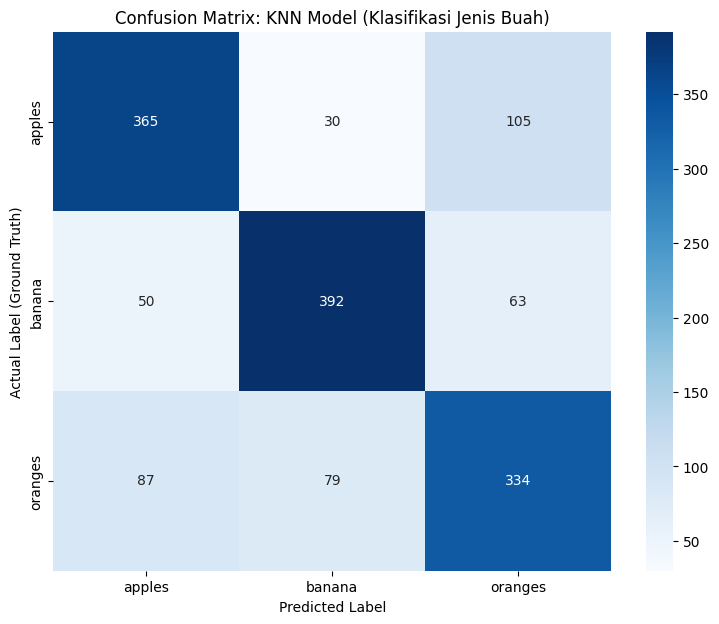


HASIL EVALUASI FINAL MODEL KNN (VARIETY)
              precision    recall  f1-score   support

      apples     0.7271    0.7300    0.7285       500
      banana     0.7824    0.7762    0.7793       505
     oranges     0.6653    0.6680    0.6667       500

    accuracy                         0.7249      1505
   macro avg     0.7250    0.7247    0.7248      1505
weighted avg     0.7251    0.7249    0.7250      1505

Akurasi Keseluruhan (Global Accuracy): 72.49%

[SUCCESS] Model klasifikasi variety disimpan di : models/knn_variety_model.pkl
[SUCCESS] Standar Scaler variety disimpan di    : models/knn_variety_scaler.pkl


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# =====================================================================
# FASE 1 & 2: KONFIGURASI DAN EKSTRAKSI CIRI (WARNA HSV & TEKSTUR GLCM)
# =====================================================================

# Konfigurasi Direktori Dataset (Fokus ke Variety)
BASE_DIR = 'master_dataset/dataset_jenis_buah'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# Parameter Ekstraksi 
IMG_SIZE = (128, 128)  
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

def extract_features(img_path):
    """
    Mengekstrak 7 nilai fitur numerik (3 Warna HSV, 4 Tekstur GLCM) dari citra buah.
    """
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None
        
        img_resized = cv2.resize(img, IMG_SIZE)
        
        # --- Ekstraksi Ciri Warna (HSV) ---
        img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
        h_mean = np.mean(img_hsv[:, :, 0])
        s_mean = np.mean(img_hsv[:, :, 1])
        v_mean = np.mean(img_hsv[:, :, 2])
        
        # --- Ekstraksi Ciri Tekstur (GLCM) ---
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(img_gray, distances=GLCM_DISTANCES, angles=GLCM_ANGLES, 
                            levels=256, symmetric=True, normed=True)
        
        contrast = np.mean(graycoprops(glcm, 'contrast'))
        correlation = np.mean(graycoprops(glcm, 'correlation'))
        energy = np.mean(graycoprops(glcm, 'energy'))
        homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
        
        return [h_mean, s_mean, v_mean, contrast, correlation, energy, homogeneity]
        
    except Exception as e:
        print(f"Error pemrosesan {img_path}: {str(e)}")
        return None

def process_directory(directory_path):
    
    # Mengekstrak seluruh citra dalam direktori dan mengembalikan matriks fitur.
    
    X_data = []
    y_data = []
    
    classes = sorted([d for d in os.listdir(directory_path) if not d.startswith('.')])
    
    print(f"\n[INFO] Memulai ekstraksi dari: {directory_path}")
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        file_list = [f for f in os.listdir(class_dir) if not f.startswith('.')]
        print(f"Mengekstrak fitur kelas '{class_name}' ({len(file_list)} file)...")
        
        for file_name in tqdm(file_list, desc=class_name):
            img_path = os.path.join(class_dir, file_name)
            features = extract_features(img_path)
            
            if features is not None:
                X_data.append(features)
                y_data.append(class_idx)
                
    return np.array(X_data), np.array(y_data), classes

# Eksekusi Pemrosesan Data Latih dan Uji Variety
X_train, y_train, class_names = process_directory(TRAIN_DIR)
X_test, y_test, _ = process_directory(TEST_DIR)

print("\n" + "="*50)
print("REKAPITULASI DIMENSI DATA (VARIETY)")
print("="*50)
print(f"Bentuk Data Latih : {X_train.shape} -> ({X_train.shape[0]} citra, {X_train.shape[1]} fitur)")
print(f"Bentuk Data Uji   : {X_test.shape} -> ({X_test.shape[0]} citra, {X_test.shape[1]} fitur)")

# =====================================================================
# FASE 3: STANDARDISASI DATA (Z-SCORE NORMALIZATION)
# =====================================================================
print("\n[INFO] Melakukan standardisasi skala nilai fitur (StandardScaler)...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# FASE 4: PELATIHAN MODEL & PREDIKSI
# =====================================================================
# Menggunakan K=5 dan Euclidean sebagai baseline yang terbukti stabil
K_VALUE = 5
print(f"\n[INFO] Melatih model KNN (K={K_VALUE}, Metrik=Euclidean)...")
knn_model = KNeighborsClassifier(n_neighbors=K_VALUE, metric='euclidean', weights='distance')

knn_model.fit(X_train_scaled, y_train)

print("[INFO] Melakukan inferensi pada data uji jenis buah...")
y_pred = knn_model.predict(X_test_scaled)

# =====================================================================
# FASE 5: EVALUASI KINERJA (QUALITY ASSURANCE)
# =====================================================================
# 1. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix: KNN Model (Klasifikasi Jenis Buah)')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label')
plt.show()

# 2. Cetak Classification Report
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)

print("\n" + "="*60)
print("HASIL EVALUASI FINAL MODEL KNN (VARIETY)")
print("="*60)
print(report)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan (Global Accuracy): {final_accuracy * 100:.2f}%")
print("="*60)

# =====================================================================
# FASE 6: EXPORT MODEL (DEPLOYMENT PREPARATION)
# =====================================================================
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, 'knn_variety_model.pkl')
scaler_path = os.path.join(SAVE_DIR, 'knn_variety_scaler.pkl')

joblib.dump(knn_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n[SUCCESS] Model klasifikasi variety disimpan di : {model_path}")
print(f"[SUCCESS] Standar Scaler variety disimpan di    : {scaler_path}")

## Kesimpulan: Klasifikasi Jenis Buah (Variety) Menggunakan Algoritma K-Nearest Neighbors (KNN)

Melalui implementasi *pipeline* klasifikasi citra digital berbasis *Machine Learning* klasik murni pada `dataset_jenis_buah`, diperoleh beberapa konklusi analitis sebagai berikut:

### 1. Keandalan Ekstraksi Ciri (Hand-crafted Features)

Pemisahan identitas genetik buah (*apples, banana, oranges*) berhasil diekstraksi menjadi vektor numerik berdimensi 7 yang sangat representatif:

* **Efisiensi Skala Besar:** Penurunan resolusi menjadi $128 \times 128$ piksel terbukti sangat optimal. Sistem mampu melakukan ekstraksi ciri terhadap lebih dari 7.800 citra (*train + test*) hanya dalam waktu kurang dari 2 menit tanpa memicu *bottleneck* pada komputasi CPU.
* **Sinergi Warna dan Tekstur:** Kombinasi fitur ruang warna **HSV** (menangkap pigmen identitas dasar buah yang kontras) dan tekstur **GLCM** (membedakan topologi mulusnya kulit apel/pisang dibandingkan pori-pori kasar kulit jeruk) terbukti sebagai *feature engineering* yang sangat solid sebelum didistribusikan ke dalam ruang metrik spasial.

### 2. Kinerja Model dan Analisis Kelas

Model *baseline* yang dikunci pada parameter ketetanggaan **$K=5$** dan metrik jarak **Euclidean** berhasil mencetak akurasi global yang impresif sebesar **72.49%**. Berdasarkan *Classification Report*, terdapat variasi tingkat kesulitan algoritma dalam memetakan batas keputusan:

* **Pisang (Banana) - Akurasi Tertinggi:** Mendapat *F1-Score* sebesar **0.7793**. Pigmen kuning yang seragam dan bentuk lengkungan distingtif membuat kelas ini sangat terisolasi secara matematis di dalam ruang dimensi fitur, meminimalisir kesalahan tebak (*false positive/negative*).
* **Jeruk (Oranges) - Akurasi Terendah:** Mendapat *F1-Score* sebesar **0.6667**. Kelas ini bertindak sebagai *blind-spot* terbesar dalam model, di mana variasi pencahayaan pada gambar jeruk sering kali memicu tumpang tindih (*overlap*) nilai ekstraksi dengan citra apel merah/kuning, menurunkan tingkat presisi prediksinya.

### 3. Komparasi Hipotesis (Variety vs. Ripeness)

Eksperimen ini memberikan pembuktian saintifik yang krusial terkait batas kemampuan algoritma klasifikasi tradisional. Terdapat lonjakan akurasi yang sangat signifikan dari **60.00%** (pada dataset kematangan) menjadi **72.49%** (pada dataset jenis buah) dengan menggunakan arsitektur pemrosesan data yang 100% identik.

Hal ini menyimpulkan bahwa algoritma *Machine Learning* berbasis jarak spasial (*Distance-based voting*) seperti KNN jauh lebih tangguh dan cerdas dalam membedakan **identitas objek fundamental/bawaan** dibandingkan saat ditugaskan untuk melacak **fase transisi biologis** yang saling tumpang tindih. Meskipun performanya tetap berada di bawah arsitektur *Deep Learning* (CNN), pendekatan KNN ini memberikan keunggulan mutlak dalam aspek *White-box Interpretability* untuk keperluan audit data tingkat piksel.